## Problem 1: Polynomial Regression
---
You want to buy huge amount of chocolates to build a chocolate house, every room in this chocolate house should be made of different types of high quality chocolates. There is only one place to buy this amount of chocolate, the "Chocolate City" of 1000 different factories and famous for its cheating prices. Chocolate Merchants Association has provided a price sheet `chocolate_data.csv` to beat the deception for 10 types of quality, the prices are per kg, but there are quality types in the market that are not mentioned in the sheet. Build a **`regression model`** that predicts the price per kilogram, and says if you want 1000kg with a quality type called "3.5" what is the price?

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('chocolate_data.csv')

In [4]:
df.head()

,chocolate name,quality,price
0,1,10,450
1,2,9,500
2,3,8,600
3,4,7,800
4,5,6,1100


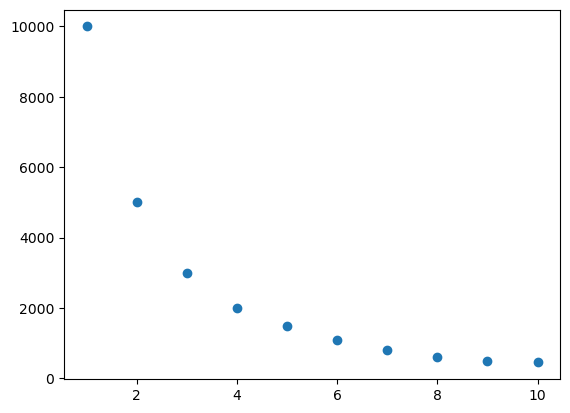

In [5]:
plt.scatter(x=df['quality '], y=df['price'])

In [6]:
X_reg = df.iloc[:, 1:2]
y_reg = df.iloc[:, -1]

In [7]:
type(X_reg), type(y_reg)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X_reg)
 
poly.fit(X_poly, y_reg)
reg = LinearRegression()
reg.fit(X_poly, y_reg)

LinearRegression()

In [31]:
reg_pred = reg.predict(X=X_poly)

<Axes: xlabel='quality '>

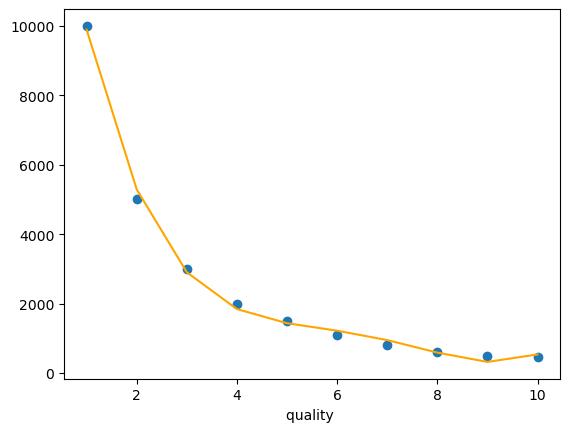

In [32]:
plt.scatter(x=df['quality '], y=df['price'])
sns.lineplot(x = df['quality '], y = reg_pred, color = 'orange')

In [12]:
prediction_of_1000kg = reg.predict([[3.5]])*1000

c:\Users\asus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
print('The price of 1000 kg of chocolate of type 3.5 is ', prediction_of_1000kg[0])

The price of 1000 kg of chocolate of type 3.5 is  4112575.757575758


## Problem 2: SVR
---
Build **`SVR model`** on the chocolate dataset `chocolate_data.csv` and provide the output graph showing the predictions of prices vs quality levels.

In [14]:
from sklearn.svm import SVR

In [92]:
from sklearn.model_selection import GridSearchCV

param = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
         'gamma': [0.1, 0.01, 0.001, 0.0001, 0.00001],
         'degree' : [4, 5, 6],
         'kernel': ['poly', 'rbf', 'sigmoid']}

grid = GridSearchCV(SVR(),param)

In [93]:
grid.fit(X=df.iloc[:, 1:2], y=df.iloc[:, -1])


GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
                         'degree': [4, 5, 6],
                         'gamma': [0.1, 0.01, 0.001, 0.0001, 1e-05],
                         'kernel': ['poly', 'rbf', 'sigmoid']})

In [94]:
grid.best_estimator_

SVR(C=1000, degree=4, gamma=0.01)

In [95]:
svr_pred=grid.predict([[10], [9], [8], [7], [6], [5], [4], [3],[2],[1], ])

c:\Users\asus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


In [96]:
# trying to find the answer of the previous question using the svr
grid.predict([[3.5]])*1000

c:\Users\asus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


array([1944642.813412])

In [97]:
svr_pred

array([ 449.90002271,  563.63924994,  733.28913494,  953.19308462,
       1213.34201473, 1500.09999785, 1797.38427102, 2088.15802464,
       2356.04334938, 2586.84240526])

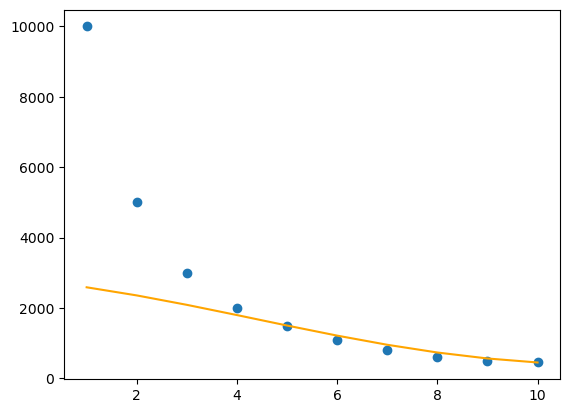

In [98]:
sns.lineplot(x=df['quality '].values, y=svr_pred,color = 'orange')
plt.scatter(x=df['quality '].values, y=df['price'].values)

plt.show()

## Problem 3:  Logistic Regression
---

- Mention 2 types of regularization used to overcome the overfitting problem and what is the difference between them.

- Using the data below in X,y. Build a **`logistic model`** to predict the output and evaluate the model with a confusion matrix.

## L1 Regularization (Lasso)
## L2 Regularization (Ridge)

They all add penalty to the loss function, the lasso adds the absolute value of the coefficients, and the ridge adds the squared value, they all shrink the coefficients of the variables, and then reducing their effects. but;
- lasso can shrink the coefficient and make them reach towards zero, so it's useful when needing for feature selecting, and when the amount of the features are large
- ridge will never make the features reach to zero, so its job only reducing their effects, its useful in the need of reducing the overfitting

In [21]:
#Write your code
X_clas = np.arange(15).reshape(-1, 1)
y_clas = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
logist = LogisticRegression().fit(X_clas, y_clas)

In [24]:
clas_pred = logist.predict(X_clas)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
report = classification_report(y_clas, clas_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [27]:
logist.classes_

array([0, 1])

<Axes: >

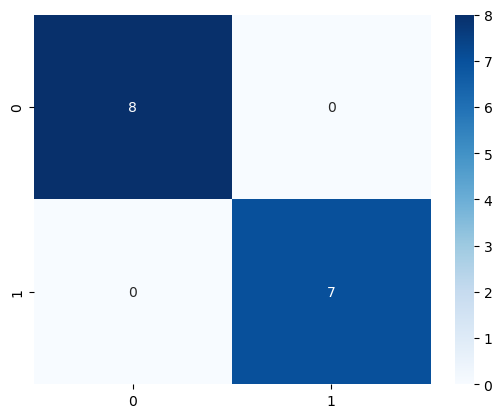

In [28]:
c_m = confusion_matrix(y_clas, clas_pred,labels=logist.classes_)
sns.heatmap(c_m, annot=True,cmap='Blues')

# Good Luck 🤗 🤗 🤗